In [1]:
import numpy as np

In [2]:
complex = np.array(["a", "b", "c", "d", "ab", "ac", "ad", "bc", "bd", "abc"])

In [3]:
len(complex[np.char.str_len(complex) == 3])

1

In [4]:
operator_brzegu = np.zeros(
    (
        len(complex[np.char.str_len(complex) == 3]),
        len(complex[np.char.str_len(complex) == 2]),
    )
)

In [17]:
for c2 in complex[np.char.str_len(complex) == 3]:
    for c1 in complex[np.char.str_len(complex) == 2]:
        if all(char in c2 for char in c1):
            i = np.where(complex[np.char.str_len(complex) == 3] == c2)[0][0]
            j = np.where(complex[np.char.str_len(complex) == 2] == c1)[0][0]
            operator_brzegu[i, j] = 1

In [35]:
operator_brzegu

array([[1., 1., 0., 1., 0.]])

In [18]:
from itertools import combinations

In [ ]:
combinations_list = []
for i in range(1, len(complex[np.char.str_len(complex) == 2]) + 1):
    combinations_list.append(
        list(combinations(complex[np.char.str_len(complex) == 2], i))
    )

combinations_list

[[(np.str_('ab'),),
  (np.str_('ac'),),
  (np.str_('ad'),),
  (np.str_('bc'),),
  (np.str_('bd'),)],
 [(np.str_('ab'), np.str_('ac')),
  (np.str_('ab'), np.str_('ad')),
  (np.str_('ab'), np.str_('bc')),
  (np.str_('ab'), np.str_('bd')),
  (np.str_('ac'), np.str_('ad')),
  (np.str_('ac'), np.str_('bc')),
  (np.str_('ac'), np.str_('bd')),
  (np.str_('ad'), np.str_('bc')),
  (np.str_('ad'), np.str_('bd')),
  (np.str_('bc'), np.str_('bd'))],
 [(np.str_('ab'), np.str_('ac'), np.str_('ad')),
  (np.str_('ab'), np.str_('ac'), np.str_('bc')),
  (np.str_('ab'), np.str_('ac'), np.str_('bd')),
  (np.str_('ab'), np.str_('ad'), np.str_('bc')),
  (np.str_('ab'), np.str_('ad'), np.str_('bd')),
  (np.str_('ab'), np.str_('bc'), np.str_('bd')),
  (np.str_('ac'), np.str_('ad'), np.str_('bc')),
  (np.str_('ac'), np.str_('ad'), np.str_('bd')),
  (np.str_('ac'), np.str_('bc'), np.str_('bd')),
  (np.str_('ad'), np.str_('bc'), np.str_('bd'))],
 [(np.str_('ab'), np.str_('ac'), np.str_('ad'), np.str_('bc')),
  (

In [ ]:
def rank_mod2(matrix):
    A = (matrix % 2).astype(int).tolist()
    rows = len(A)
    cols = len(A[0])
    rank = 0
    for col in range(cols):
        pivot = -1
        for row in range(rank, rows):
            if A[row][col] == 1:
                pivot = row
                break
        if pivot == -1:
            continue
        A[rank], A[pivot] = A[pivot], A[rank]
        for row in range(rows):
            if row != rank and A[row][col] == 1:
                for c in range(cols):
                    A[row][c] ^= A[rank][c]
        rank += 1
    return rank


operator1 = np.array(
    [[1, 1, 1, 0, 0], [1, 0, 0, 1, 1], [0, 1, 0, 1, 0], [0, 0, 1, 0, 1]]
)

In [44]:
import sympy as sp

In [45]:
rank_mod2(operator1)

3

In [36]:
np.linalg.matrix_rank(operator_brzegu)

np.int64(1)

In [ ]:
dimz1 = (
    len(complex[np.char.str_len(complex) == 2])
    - np.linalg.matrix_rank(operator1)
    - np.linalg.matrix_rank(operator_brzegu)
)
dimz1

np.int64(1)

In [ ]:
beta1 = (
    len(complex[np.char.str_len(complex) == 2])
    - np.linalg.matrix_rank(operator1)
    - np.linalg.matrix_rank(operator_brzegu)
)
beta1

np.int64(0)

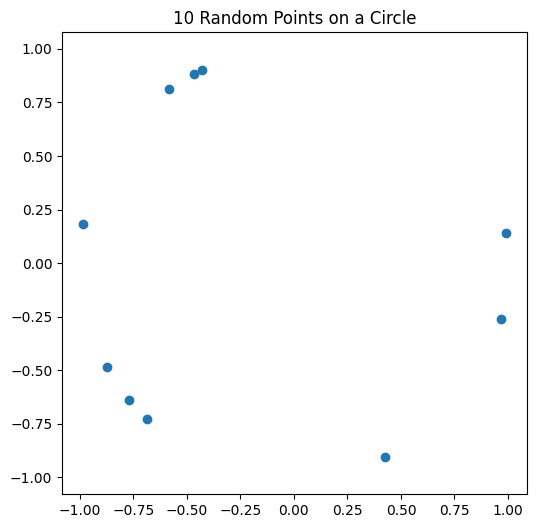

array([[-0.98346838,  0.18107997],
       [-0.68722488, -0.72644475],
       [-0.43001237,  0.902823  ],
       [ 0.96595867, -0.25869646],
       [-0.46647205,  0.88453594],
       [-0.58210097,  0.81311651],
       [ 0.99030733,  0.13889343],
       [-0.7685285 , -0.63981556],
       [-0.87451632, -0.48499609],
       [ 0.42670356, -0.90439155]])

In [ ]:
import matplotlib.pyplot as plt

# Generate 10 random points on a circle
angles = np.random.uniform(0, 2 * np.pi, 10)
x = np.cos(angles)
y = np.sin(angles)
points = np.column_stack((x, y))

# Plot the points
plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1])
plt.axis("equal")
plt.title("10 Random Points on a Circle")
plt.show()

points

In [ ]:
def metryka_minkowskiego(x, y, p):
    if p >= 1 and p != float("inf"):
        wynik = (np.sum((abs(x - y)) ** p)) ** (1 / p)
    elif p < 1 and p >= 0:
        wynik = np.sum(abs((x - y)) ** p)
    elif p == float("inf"):
        wynik = np.max(abs(x - y))
    return wynik


def macierz_odleglosci(x, p):
    rozmiar = len(x)
    D = np.zeros((rozmiar, rozmiar))
    for i in range(len(x)):
        for j in range(i, len(x)):
            D[j, i] = D[i, j] = metryka_minkowskiego(x[i], x[j], p)
    # return print(f"Macierz odległości dla p = {p} wygląda następująco:\n{np.round(D,2)},\na średnica zbioru:\n{np.max(D)}")
    return D, np.max(D)  # dla macierzy odległości i średnicy zbioru

In [ ]:
matrixD, max = macierz_odleglosci(points, 2)

In [ ]:
nazwy_pkt = [f"point{i}" for i in range(len(points))]
nazwy_pkt

['point0',
 'point1',
 'point2',
 'point3',
 'point4',
 'point5',
 'point6',
 'point7',
 'point8',
 'point9']

In [ ]:
odl_uniq = np.unique(
    matrixD.reshape(
        -1,
    ),
    sorted=True,
)
odl_uniq

array([0.        , 0.04078879, 0.11880613, 0.13590724, 0.17657348,
       0.18762325, 0.30557411, 0.39833475, 0.67492804, 0.74870955,
       0.8412599 , 0.84856857, 0.87300372, 0.90951996, 0.95465246,
       1.12805214, 1.18578782, 1.22416507, 1.3306401 , 1.36713779,
       1.42902697, 1.45726648, 1.46484362, 1.54314611, 1.55399021,
       1.57934381, 1.6127295 , 1.62603523, 1.63651732, 1.64944586,
       1.71086078, 1.71808157, 1.77586528, 1.77955986, 1.81600181,
       1.83271331, 1.85433538, 1.88288918, 1.88757105, 1.92351012,
       1.96641943, 1.97422649, 1.99186358, 1.99841665, 1.99950599,
       1.99999665])

In [85]:
odleglosc = 1
odcinki = []
for i, pointA in enumerate(points):
    for j, pointB in enumerate(points):
        if metryka_minkowskiego(pointA, pointB, 2) < odleglosc and i != j:
            odcinki.append([pointA, pointB])

In [86]:
odcinki

[[array([-0.98346838,  0.18107997]), array([-0.68722488, -0.72644475])],
 [array([-0.98346838,  0.18107997]), array([-0.43001237,  0.902823  ])],
 [array([-0.98346838,  0.18107997]), array([-0.46647205,  0.88453594])],
 [array([-0.98346838,  0.18107997]), array([-0.58210097,  0.81311651])],
 [array([-0.98346838,  0.18107997]), array([-0.7685285 , -0.63981556])],
 [array([-0.98346838,  0.18107997]), array([-0.87451632, -0.48499609])],
 [array([-0.68722488, -0.72644475]), array([-0.98346838,  0.18107997])],
 [array([-0.68722488, -0.72644475]), array([-0.7685285 , -0.63981556])],
 [array([-0.68722488, -0.72644475]), array([-0.87451632, -0.48499609])],
 [array([-0.43001237,  0.902823  ]), array([-0.98346838,  0.18107997])],
 [array([-0.43001237,  0.902823  ]), array([-0.46647205,  0.88453594])],
 [array([-0.43001237,  0.902823  ]), array([-0.58210097,  0.81311651])],
 [array([ 0.96595867, -0.25869646]), array([0.99030733, 0.13889343])],
 [array([ 0.96595867, -0.25869646]), array([ 0.426703

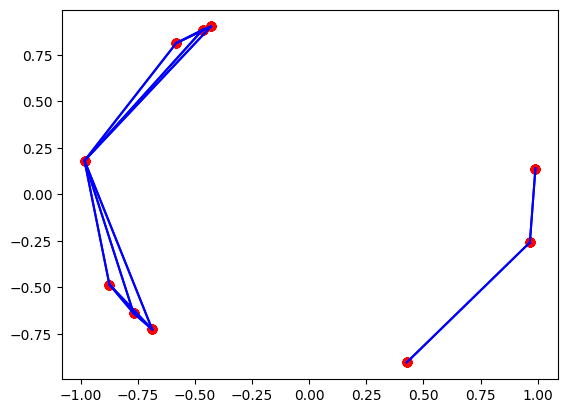

In [ ]:
for i in odcinki:
    plt.plot([i[0][0], i[1][0]], [i[0][1], i[1][1]], "b-")
    plt.scatter(points[:, 0], points[:, 1], c="red")

In [ ]:
for i in odl_uniq:
    plt.figure(figsize=(6, 6))
    for j, pointA in enumerate(points):
        for k, pointB in enumerate(points):
            if metryka_minkowskiego(pointA, pointB, 2) < i and j != k:
                plt.plot([pointA[0], pointB[0]], [pointA[1], pointB[1]], "b-")
    plt.scatter(points[:, 0], points[:, 1], c="red")
    plt.title(f"dist less than {i:.2f}")
    plt.axis("equal")
    plt.show()

: 

### Macierz trojkatna

In [ ]:
import numpy as np

random01matrix = np.random.randint(0, 2, size=(10, 10))
random01matrix

array([[1, 0, 1, 0, 1, 0, 1, 1, 1, 0],
       [1, 1, 0, 0, 0, 1, 1, 0, 1, 1],
       [0, 0, 0, 0, 0, 1, 0, 1, 1, 1],
       [1, 0, 0, 0, 0, 0, 1, 1, 0, 0],
       [1, 0, 0, 0, 0, 1, 0, 1, 1, 1],
       [0, 1, 1, 1, 0, 1, 1, 0, 0, 1],
       [1, 1, 0, 1, 0, 1, 0, 1, 0, 1],
       [1, 1, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 1, 1, 1, 1, 1, 0],
       [0, 0, 1, 1, 0, 1, 0, 1, 0, 0]], dtype=int32)

In [66]:
random01matrix[:, 0]

array([1, 1, 0, 1, 1, 0, 1, 1, 0, 0], dtype=int32)

In [39]:
random01matrix[0, :]

array([1, 0, 1, 0, 1, 1, 0, 0, 1, 1], dtype=int32)

In [40]:
random01matrix.shape

(10, 10)

In [41]:
if random01matrix.shape[0] > random01matrix.shape[1]:
    random01matrix = random01matrix.T

In [ ]:
import numpy as np

# random01matrix = np.random.randint(0, 2, size = (10, 10))
# random01matrix
random01matrix = np.array(
    [
        [
            0,
            1,
        ],
        [
            1,
            1,
        ],
        [
            1,
            0,
        ],
        [
            1,
            0,
        ],
        [
            0,
            1,
        ],
        [
            0,
            0,
        ],
        [
            0,
            0,
        ],
        [
            0,
            0,
        ],
        [
            0,
            0,
        ],
        [
            0,
            0,
        ],
    ]
)


transposed = False
if random01matrix.shape[0] > random01matrix.shape[1]:
    random01matrix = random01matrix.T
    transposed = True  # przyda sie jesli bede chcial wyswietlac zredukowana macierz,
    # aby wiedziec czy musze wrocic do poprzedniej formy

nrows = len(random01matrix[:, 0])
ncols = len(random01matrix[0, :])
rowstodrop = []
swappedcols = []
swappedrows = []

for i in range(nrows):

    # -- Blok redukcji gaussowskiej -- #
    if random01matrix[i, i] == 1:
        for k in range(i + 1, nrows):
            if random01matrix[k, i] == 1:
                random01matrix[k, i] += random01matrix[i, i]
                random01matrix[k, i] %= 2
    # -- Blok redukcji gaussowskiej -- #

    else:  # wymyslec logike co się będzie działo, jeśli dupnie się nam tutaj zero
        if i == ncols - 1:
            rowstodrop.append(i)

        else:
            for k in range(i + 1, ncols):
                if random01matrix[i, k] == 1:
                    random01matrix[i, i], random01matrix[i, k] = (
                        random01matrix[i, k].copy(),
                        random01matrix[i, i].copy(),
                    )
                    swappedcols.append((i, k))
                    break
                elif (
                    random01matrix[k, i] == 1
                ):  # tu dolozyc warunek zeby sprawdzalo w tym samym rzedzie wiersze i kolumny
                    random01matrix[i, i], random01matrix[k, i] = (
                        random01matrix[k, i].copy(),
                        random01matrix[i, i].copy(),
                    )
                    swappedrows.append((i, k))
                    break
                if k == ncols - 1:
                    rowstodrop.append(i)

            # -- Blok redukcji gaussowskiej -- #
            if random01matrix[i, i] == 1:
                for k in range(i + 1, nrows):
                    if random01matrix[k, i] == 1:
                        random01matrix[k, i] += random01matrix[i, i]
                        random01matrix[k, i] %= 2
            # -- Blok redukcji gaussowskiej -- #

            # pass # usuniecie wiersza, tylko co z iteracjami?
            # albo w sumie zostawic to w pizdu, zajac sie tym na koniec


print(f"Rzad macierzy wynosi {min(random01matrix.shape) - len(rowstodrop)}")

Rzad macierzy wynosi 2


(10, 10)

https://docs.google.com/document/d/1X8nqiktRKyM2kjBmDO1G3zajBgPIrEMIYKeQ0uFC48/edit?usp=sharing